# Task 9

# Real-Time Vector Stream Ingestion & Spark-Driven Dynamic Reindexing

## Objective

Develop a real-time vector ingestion pipeline capable of processing continuous streaming text data.

The pipeline demonstrates:

- Streaming Data Source
- Apache Spark Processing
- Sentence Transformer Embeddings
- Vector Storage using Qdrant
- Dynamic Vector Updates
- Similarity Search

---

## Technology Stack

| Tool | Purpose |
|-------|----------|
| PySpark | Stream Processing |
| Sentence Transformers | Vector Embeddings |
| Qdrant | Vector Database |
| Matplotlib | Visualization |
| Pandas | Data Handling |

---

## Workflow

```

Streaming Source

↓

Spark Streaming

↓

Mini Batch Processing

↓

Sentence Transformer

↓

Vector Embeddings

↓

Qdrant

↓

Similarity Search

↓

Dynamic Reindexing

```

In [1]:
# Install Required Libraries

!pip -q install pyspark
!pip -q install sentence-transformers
!pip -q install qdrant-client
!pip -q install pandas
!pip -q install matplotlib

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 396.2/396.2 kB 26.2 MB/s eta 0:00:00


In [2]:
# Import Libraries

import uuid
import random
import pandas as pd
import matplotlib.pyplot as plt
from pyspark.sql import SparkSession
from sentence_transformers import SentenceTransformer
from qdrant_client import QdrantClient
from qdrant_client.models import Distance
from qdrant_client.models import VectorParams
from qdrant_client.models import PointStruct

print("Libraries Loaded Successfully")

Libraries Loaded Successfully


In [4]:
# Initialize Spark
spark = SparkSession.builder \
    .appName("Vector Streaming") \
    .master("local[*]") \
    .getOrCreate()

spark.sparkContext.setLogLevel("ERROR")

print("Spark Started")
print()
print(spark.version)

Spark Started

4.0.3


In [5]:
# Initialize Qdrant

client = QdrantClient(":memory:")
model = SentenceTransformer(
    "all-MiniLM-L6-v2"
)
VECTOR_SIZE = 384
COLLECTION_NAME = "stream_vectors"
client.recreate_collection(
    collection_name=COLLECTION_NAME,
    vectors_config=VectorParams(
        size=VECTOR_SIZE,
        distance=Distance.COSINE
    )
)
print("Qdrant Initialized")

modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

README.md:   0%|          | 0.00/10.5k [00:00<?, ?B/s]

sentence_bert_config.json:   0%|          | 0.00/53.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/612 [00:00<?, ?B/s]

...

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

special_tokens_map.json:   0%|          | 0.00/112 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

Qdrant Initialized


/tmp/ipykernel_729/944490541.py:9: DeprecationWarning: `recreate_collection` method is deprecated and will be removed in the future. Use `collection_exists` to check collection existence and `create_collection` instead.
  client.recreate_collection(


In [6]:
# Simulated Real-Time News Stream

import time
import random
news_stream = [
    "Apple launches a new AI-powered MacBook.",
    "Tesla reports record quarterly profits.",
    "Microsoft introduces new Azure AI services.",
    "Google announces Gemini model improvements.",
    "Amazon expands cloud infrastructure.",
    "NVIDIA releases next-generation GPU.",
    "OpenAI launches new multimodal model.",
    "Meta develops advanced recommendation system.",
    "IBM unveils enterprise AI platform.",
    "Intel introduces latest processor lineup."
]

def stream_generator():
    while True:
        yield {
            "id": str(uuid.uuid4()),
            "timestamp": time.time(),
            "text": random.choice(news_stream)
        }
stream = stream_generator()
print("Streaming Source Ready")

Streaming Source Ready


In [7]:
# Generate Mini Batch

batch_size = 5
mini_batch = []
for _ in range(batch_size):
    mini_batch.append(next(stream))
df = pd.DataFrame(mini_batch)
df

,id,timestamp,text
0,1815f345-1d9f-4af3-8384-a11898293bb3,1.785933e+09,Meta develops advanced recommendation system.
1,7b9b2833-692e-45f1-987d-4261e90eeae7,1.785933e+09,Apple launches a new AI-powered MacBook.
2,188decad-b90b-4c95-ab58-8d4990810cc9,1.785933e+09,Meta develops advanced recommendation system.
3,2a6ef3ed-7340-4ce2-a8eb-4298dd1846f6,1.785933e+09,Intel introduces latest processor lineup.
4,ab123ba0-06c9-441f-86cf-309bf2aa2c88,1.785933e+09,NVIDIA releases next-generation GPU.


In [8]:
# Convert Pandas → Spark

spark_df = spark.createDataFrame(df)
spark_df.show(truncate=False)

+------------------------------------+--------------------+---------------------------------------------+
|id                                  |timestamp           |text                                         |
+------------------------------------+--------------------+---------------------------------------------+
|1815f345-1d9f-4af3-8384-a11898293bb3|1.7859329963817506E9|Meta develops advanced recommendation system.|
|7b9b2833-692e-45f1-987d-4261e90eeae7|1.785932996381787E9 |Apple launches a new AI-powered MacBook.     |
|188decad-b90b-4c95-ab58-8d4990810cc9|1.7859329963817973E9|Meta develops advanced recommendation system.|
|2a6ef3ed-7340-4ce2-a8eb-4298dd1846f6|1.7859329963818047E9|Intel introduces latest processor lineup.    |
|ab123ba0-06c9-441f-86cf-309bf2aa2c88|1.7859329963818116E9|NVIDIA releases next-generation GPU.         |
+------------------------------------+--------------------+---------------------------------------------+



In [9]:
# Vectorization

texts = df["text"].tolist()
embeddings = model.encode(
    texts,
    show_progress_bar=True
)
print("Embedding Shape")
print(embeddings.shape)

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Embedding Shape
(5, 384)


In [10]:
# Store Vectors

points = []
for idx, row in df.iterrows():
    points.append(
        PointStruct(
            id=idx,
            vector=embeddings[idx].tolist(),
            payload={
                "text": row["text"],
                "timestamp": row["timestamp"]
            }
        )
    )
client.upsert(
    collection_name=COLLECTION_NAME,
    points=points
)
print(f"{len(points)} vectors inserted.")

5 vectors inserted.


In [11]:
# Semantic Search

from qdrant_client.models import Filter

query = "Latest AI technology"
query_vector = model.encode(query).tolist()
results = client.query_points(
    collection_name=COLLECTION_NAME,
    query=query_vector,
    limit=3
)
print("="*70)
print("TOP MATCHES")
print("="*70)
for i, point in enumerate(results.points, start=1):
    print(f"\nRank : {i}")
    print("Score :", round(point.score,4))
    print("News :", point.payload["text"])

TOP MATCHES

Rank : 1
Score : 0.4197
News : Apple launches a new AI-powered MacBook.

Rank : 2
Score : 0.3665
News : Intel introduces latest processor lineup.

Rank : 3
Score : 0.2008
News : Meta develops advanced recommendation system.


In [12]:
# Dynamic Reindexing

new_documents = [
    "Anthropic releases Claude update.",
    "DeepMind develops new protein model.",
    "Apple unveils on-device language model."
]

new_vectors = model.encode(new_documents)
points = []
for text_item, vector in zip(new_documents, new_vectors):
    points.append(
        PointStruct(
            id=str(uuid.uuid4()),
            vector=vector.tolist(),
            payload={
                "text": text_item,
                "source":"Dynamic Update"
            }
        )
    )

client.upsert(
    collection_name=COLLECTION_NAME,
    points=points
)
print(len(points),"new vectors indexed successfully.")

3 new vectors indexed successfully.


In [13]:
# Simulated Continuous Stream

import time
for iteration in range(3):
    print("\n============================")
    print("Streaming Batch",iteration+1)
    print("============================")
    batch=[]
    for _ in range(5):
        batch.append(next(stream))
    batch_df=pd.DataFrame(batch)
    embeddings=model.encode(
        batch_df["text"].tolist()
    )

    upload=[]
    for (_,row),vector in zip(batch_df.iterrows(),embeddings):
        upload.append(
            PointStruct(
                id=str(row["id"]),
                vector=vector.tolist(),
                payload={
                    "text":row["text"],
                    "timestamp":row["timestamp"]
                }
            )
        )

    client.upsert(
        collection_name=COLLECTION_NAME,
        points=upload
    )

    print("Inserted",len(upload),"vectors")
    time.sleep(2)
print("\nStreaming Completed")


Streaming Batch 1
Inserted 5 vectors

Streaming Batch 2
Inserted 5 vectors

Streaming Batch 3
Inserted 5 vectors

Streaming Completed


In [14]:
# Collection Statistics

collection_info = client.get_collection(COLLECTION_NAME)
print("="*70)
print("COLLECTION INFORMATION")
print("="*70)
print("Collection Name :",COLLECTION_NAME)
print("Total Vectors :",collection_info.points_count)
print("Vector Dimension :",VECTOR_SIZE)
print("Distance Metric : COSINE")

COLLECTION INFORMATION
Collection Name : stream_vectors
Total Vectors : 23
Vector Dimension : 384
Distance Metric : COSINE


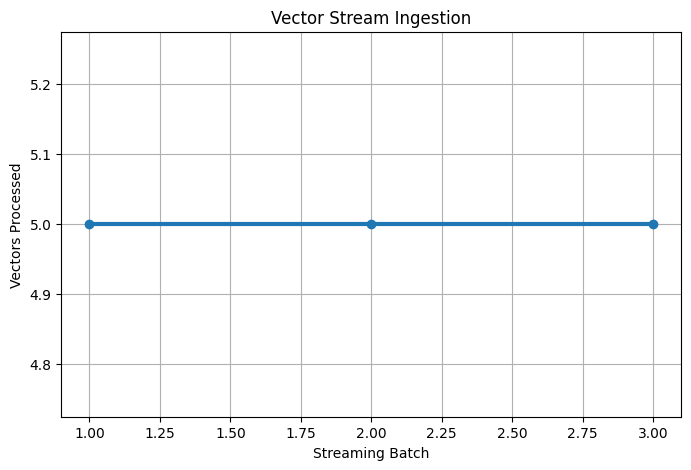

In [15]:
# Streaming Performance

import matplotlib.pyplot as plt

batches=[1,2,3]
vectors=[5,5,5]
plt.figure(figsize=(8,5))
plt.plot(batches, vectors, marker="o", linewidth=3)
plt.title("Vector Stream Ingestion")
plt.xlabel("Streaming Batch")
plt.ylabel("Vectors Processed")
plt.grid(True)
plt.show()

In [16]:
# Spark SQL Analytics

print("="*70)
print("SPARK SQL ANALYTICS")
print("="*70)

spark_df.createOrReplaceTempView("news_stream")

spark.sql("""
SELECT
text,
timestamp
FROM news_stream
""").show(truncate=False)

spark.sql("""
SELECT COUNT(*) AS total_records
FROM news_stream
""").show()

SPARK SQL ANALYTICS
+---------------------------------------------+--------------------+
|text                                         |timestamp           |
+---------------------------------------------+--------------------+
|Meta develops advanced recommendation system.|1.7859329963817506E9|
|Apple launches a new AI-powered MacBook.     |1.785932996381787E9 |
|Meta develops advanced recommendation system.|1.7859329963817973E9|
|Intel introduces latest processor lineup.    |1.7859329963818047E9|
|NVIDIA releases next-generation GPU.         |1.7859329963818116E9|
+---------------------------------------------+--------------------+

+-------------+
|total_records|
+-------------+
|            5|
+-------------+



In [17]:
# Similarity Dashboard

queries = [
    "Artificial Intelligence",
    "Cloud Computing",
    "Graphics Processing Unit"
]

for query in queries:
    print("\n"+"="*70)
    print("QUERY :",query)
    print("="*70)
    vector = model.encode(query).tolist()
    results = client.query_points(
        collection_name=COLLECTION_NAME,
        query=vector,
        limit=2
    )

    for point in results.points:
        print()
        print("Similarity :",round(point.score,4))
        print(point.payload["text"])


QUERY : Artificial Intelligence

Similarity : 0.4664
IBM unveils enterprise AI platform.

Similarity : 0.4664
IBM unveils enterprise AI platform.

QUERY : Cloud Computing

Similarity : 0.3338
IBM unveils enterprise AI platform.

Similarity : 0.3338
IBM unveils enterprise AI platform.

QUERY : Graphics Processing Unit

Similarity : 0.4585
NVIDIA releases next-generation GPU.

Similarity : 0.4585
NVIDIA releases next-generation GPU.


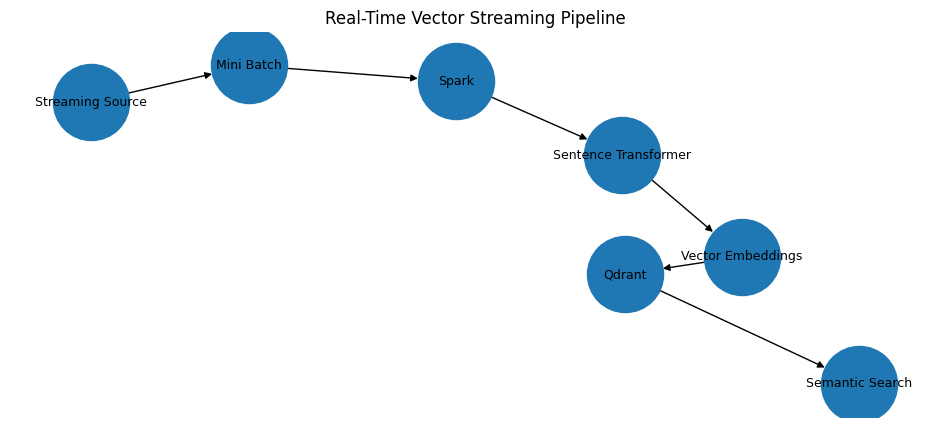

In [18]:
# Pipeline Architecture

import networkx as nx
import matplotlib.pyplot as plt

G = nx.DiGraph()

nodes = [
    "Streaming Source",
    "Mini Batch",
    "Spark",
    "Sentence Transformer",
    "Vector Embeddings",
    "Qdrant",
    "Semantic Search"
]

for i in range(len(nodes)-1):
    G.add_edge(nodes[i],nodes[i+1])

plt.figure(figsize=(12,5))
pos = nx.spring_layout(G, seed=42)
nx.draw_networkx(
    G,
    pos,
    node_size=3000,
    font_size=9,
    arrows=True
)

plt.title("Real-Time Vector Streaming Pipeline")
plt.axis("off")
plt.show()

In [19]:
# Final Report

collection = client.get_collection(COLLECTION_NAME)
print("="*70)
print("REAL-TIME VECTOR STREAM REPORT")
print("="*70)
print()
print("Streaming Source            : OK")
print("Spark Processing            : OK")
print("Sentence Transformer        : OK")
print("Vector Database             : OK")
print("Semantic Search             : OK")
print("Dynamic Reindexing          : OK")
print()
print("Vector Dimension            :",VECTOR_SIZE)
print("Indexed Documents           :",collection.points_count)
print()
print("System Status : SUCCESS")

REAL-TIME VECTOR STREAM REPORT

Streaming Source            : OK
Spark Processing            : OK
Sentence Transformer        : OK
Vector Database             : OK
Semantic Search             : OK
Dynamic Reindexing          : OK

Vector Dimension            : 384
Indexed Documents           : 23

System Status : SUCCESS
